In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import matplotlib.pyplot as plt
plt.rcParams['image.origin']='lower'
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle, Rectangle

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3, plot_data
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer


# Make the nominal Fresnel model figure. 

In [3]:
Nwaves = 15
wavelength_c = 650e-9
bw = 0.10
waves = np.linspace(wavelength_c * (1-bw/2), wavelength_c * (1+bw/2), Nwaves )
bandpasses = waves.reshape(3,5)
print(bandpasses)

Nwaves_per_bp = bandpasses.shape[1]
control_waves = bandpasses[:, Nwaves_per_bp//2]
print(control_waves)

[[6.17500000e-07 6.22142857e-07 6.26785714e-07 6.31428571e-07
  6.36071429e-07]
 [6.40714286e-07 6.45357143e-07 6.50000000e-07 6.54642857e-07
  6.59285714e-07]
 [6.63928571e-07 6.68571429e-07 6.73214286e-07 6.77857143e-07
  6.82500000e-07]]
[6.26785714e-07 6.50000000e-07 6.73214286e-07]


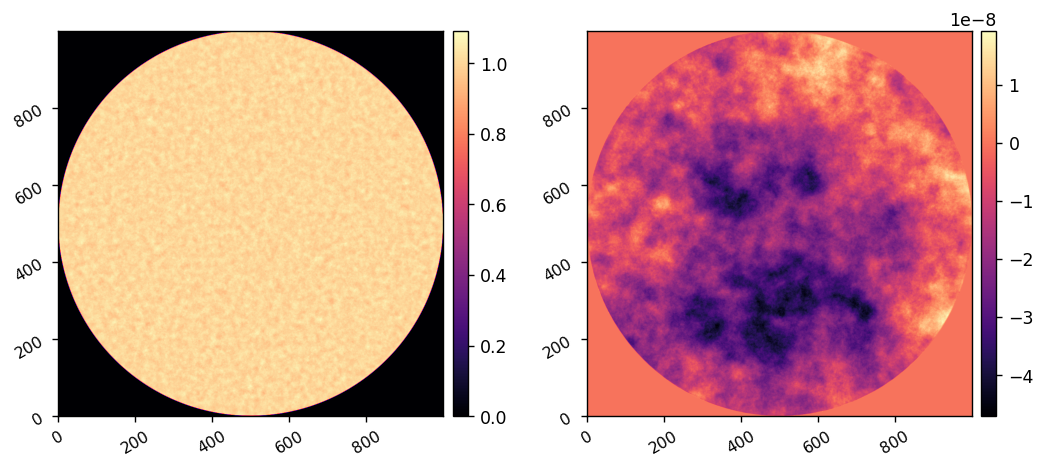

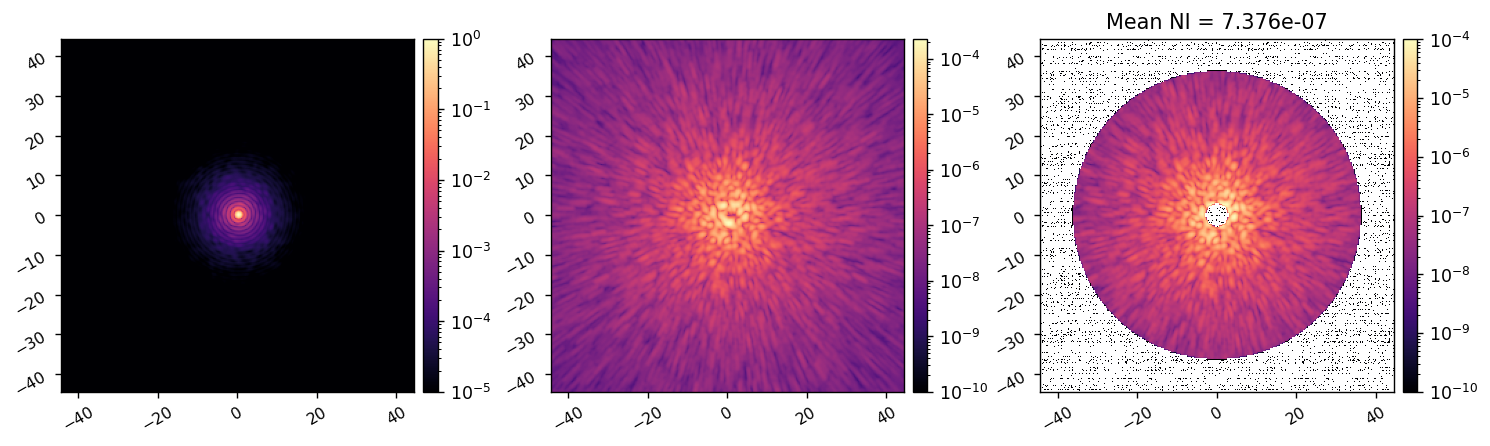

In [4]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True
AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

I.bandpasses = bandpasses

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

reload(utils)
I.reset_dms()
iwa = 3
owa = 36
control_mask = utils.create_annular_focal_plane_mask(
    I.npsf, 
    I.psf_pixelscale_lamDc, 
    irad=iwa, 
    orad=owa, 
    edge=None, 
    rotation=0,
)
mean_ni0 = xp.mean(ref_coro_im[control_mask])

imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask,
    '', '', f'Mean NI = {mean_ni0:.3e}',
    pxscl=I.psf_pixelscale_lamDc, 
    lognorm=True, vmin1=1e-5, vmin2=1e-10, vmin3=1e-10,
)

Text(0.5, 0, 'X [$\\lambda/D$]')

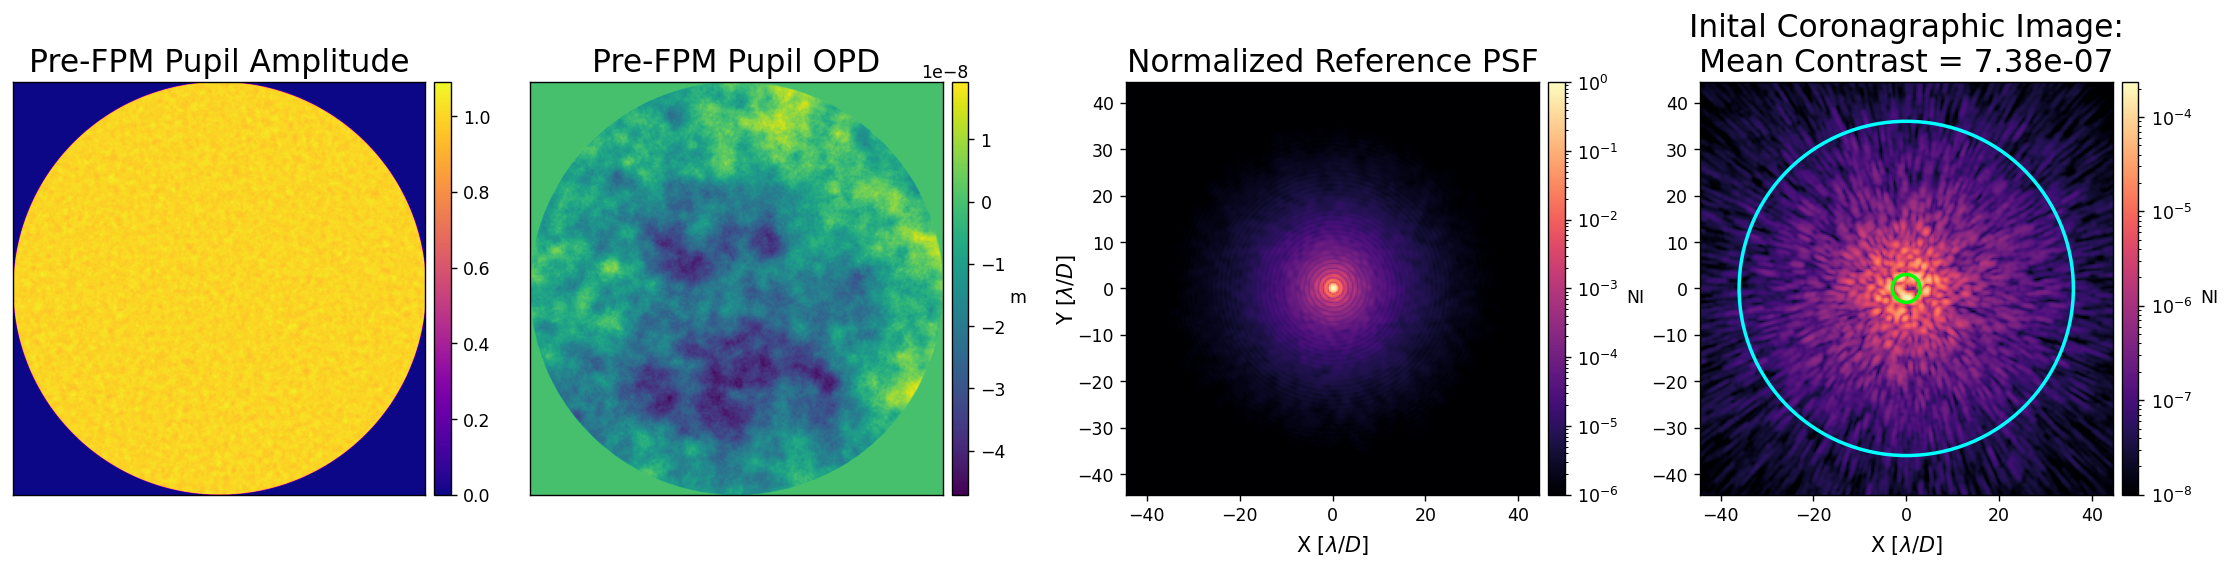

In [5]:
fig,ax = plt.subplots(nrows=1, ncols=4, figsize=(18,12), dpi=125)
ext = I.psf_pixelscale_lamDc*I.npsf/2
extent = [-ext, ext, -ext, ext]

patch1 = Circle((0,0), 3, fill=False, color='lime', linewidth=2.0)
patch2 = Circle((0,0), 36, fill=False, color='cyan', linewidth=2.0)

w = 0.275
tfs = 18

im1 = ax[0].imshow( ensure_np_array(AMP), cmap='plasma')
ax[0].set_title(f'Pre-FPM Pupil Amplitude', fontsize=tfs)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im1, cax=cax)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_position([0, 0, w, w]) # [left, bottom, width, height]

im2 = ax[1].imshow( ensure_np_array(OPD), cmap='viridis')
ax[1].set_title(f'Pre-FPM Pupil OPD', fontsize=tfs)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im2, cax=cax,)
cbar.ax.set_ylabel('m', rotation=0, labelpad=7)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_position([0.23, 0, w, w])

im3 = ax[2].imshow( ensure_np_array(ref_psf), norm=LogNorm(vmax=1, vmin=1e-6), cmap='magma', extent=extent)
ax[2].set_title(f'Normalized Reference PSF', fontsize=tfs)
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im3, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=10)
ax[2].set_position([0.495, 0, w, w])

im4 = ax[3].imshow( ensure_np_array(ref_coro_im), norm=LogNorm(vmin=1e-8), cmap='magma', extent=extent)
ax[3].set_title(f'Inital Coronagraphic Image:\nMean Contrast = {mean_ni0:.2e}', fontsize=tfs)
divider = make_axes_locatable(ax[3])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im4, cax=cax,)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=10)
ax[3].add_patch(patch1)
ax[3].add_patch(patch2)
ax[3].set_position([0.75, 0, w, w])

ax[2].set_ylabel('Y [$\lambda/D$]', fontsize=12, labelpad=0)
ax[2].set_xlabel('X [$\lambda/D$]', fontsize=12, labelpad=5)
ax[3].set_xlabel('X [$\lambda/D$]', fontsize=12, labelpad=5)

# plt.subplots_adjust(wspace=0.25)
# fig.savefig('../figs/sim_fresnel_model.pdf', format='pdf', bbox_inches="tight")

# Make the figure for broadband aEFC and EFC with model errors. 

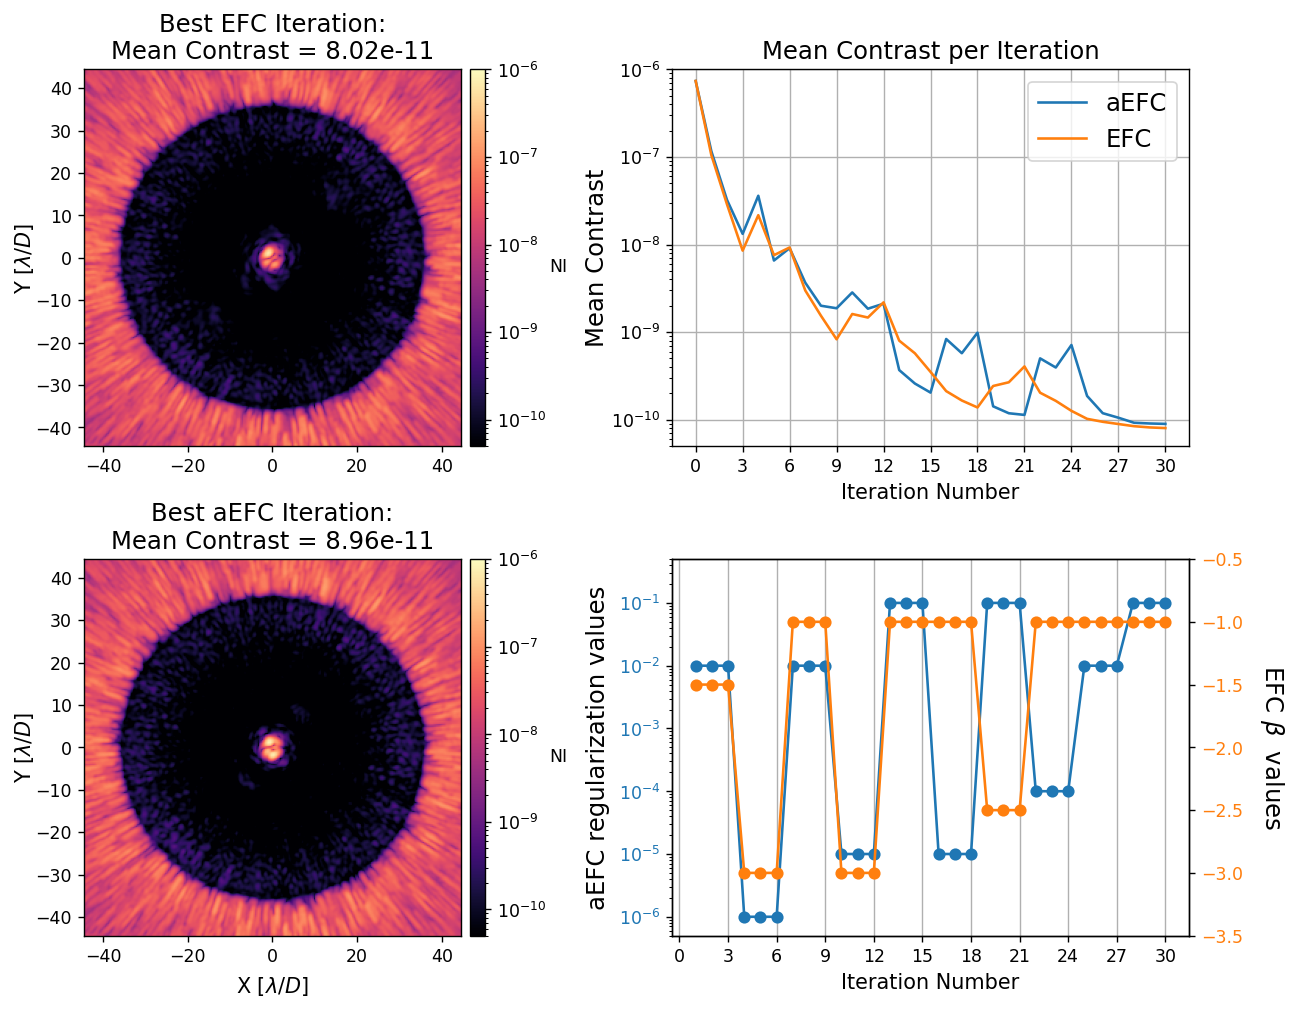

In [6]:

efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241220}_efc_run_with_ME_2.pkl')
aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20250310}_aefc_run_with_ME.pkl')

import aefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_both_with_reg_conds(
    efc_data,  aefc_data,
    im1vmin=5e-11, im1vmax=1e-6, 
    im2vmin=5e-11, im2vmax=1e-6, 
    vmin=5e-11, vmax=1e-6,
    xticks=np.linspace(0,30,11),
    # fname='../figs/sim_bb_with_me.pdf',
)